In [1]:
!pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.4 MB 5.2 MB/s 
     |████████████████████████████████| 9.8 MB 48.6 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2


In [2]:
import os 
import pandas as pd
import seaborn as sns
import pmdarima as pm

from matplotlib import pyplot
import matplotlib.pyplot as plt

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.ar_model import AutoReg,ARResults
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.statespace.sarimax import SARIMAX,SARIMAXResults
from pmdarima.arima import auto_arima 

import scipy
from scipy.fft import fft, fftfreq

import numpy as np
from numpy import polyfit

from math import sqrt

import warnings

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
!gdown --id "1JnC5mPCtSaI-NC_oUUs0_HSpEX35FUkn"

/usr/local/lib/python3.7/dist-packages/gdown/cli.py:131: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  category=FutureWarning,
Downloading...
From: https://drive.google.com/uc?id=1JnC5mPCtSaI-NC_oUUs0_HSpEX35FUkn
To: /content/data.csv
100% 358k/358k [00:00<00:00, 90.9MB/s]


# Data

In [ ]:
df=pd.read_csv('/Users/mac/Personal/learning_zone/Projects/End to end Weather Forecast/Temprature-Forecast-using-Microsoft-Azure/data/106.809947;10.876685.csv',parse_dates=True)
df=df[:8036]
df['DATE']=pd.to_datetime(df['DATE'])
data=df[['DATE','T2M']]
data.set_index(keys='DATE',inplace=True)

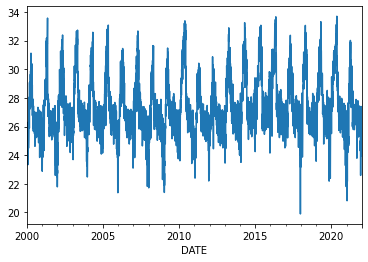

In [ ]:
data['T2M'].plot()

In [ ]:
data

,T2M
DATE,
2000-01-01,25.51
2000-01-02,25.76
2000-01-03,25.76
2000-01-04,25.87
2000-01-05,26.12
...,...
2021-12-27,26.42
2021-12-28,25.58
2021-12-29,25.67


In [5]:
train, test = data[data.index < '2020-01-01'].values, data[data.index >= '2020-01-01'].values
st=len(train)
end=len(train)+len(test)-1
print(st,end,len(test))

7305 8035 731


In [ ]:
test

# Plot

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
No handles with labels found to put in legend.


Text(0, 0.5, 'frequency')

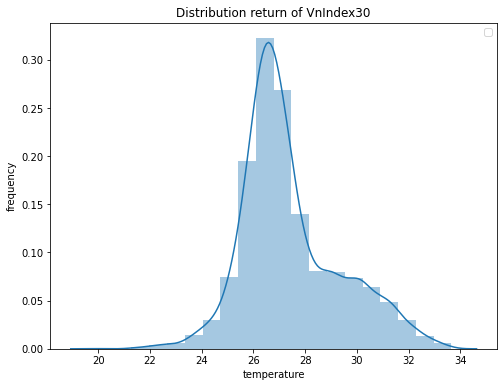

In [ ]:
plt.figure(figsize = (8, 6))
sns.distplot(train, bins = 20)
#plt.axvline(x=mean, label='mean return', c='red')
plt.title('Distribution return of VnIndex30')
plt.legend()
plt.xlabel('temperature')
plt.ylabel('frequency')

<Figure size 576x432 with 0 Axes>

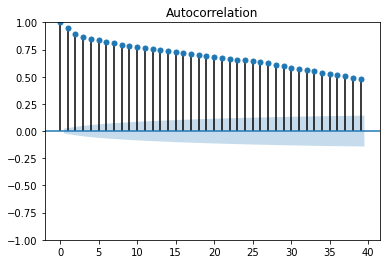

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 6))
ax1 = plot_acf(train)

/usr/local/lib/python3.7/dist-packages/statsmodels/graphics/tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


<Figure size 576x432 with 0 Axes>

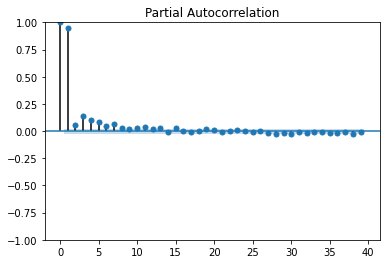

In [ ]:
plt.figure(figsize = (8, 6))
ax2 = plot_pacf(train)

In [ ]:
def adfuller_test(T2M):
    result=adfuller(T2M)
    print('p-value: ',result[1])
    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")
adfuller_test(train)

p-value:  2.0696947837186987e-09
Stationary


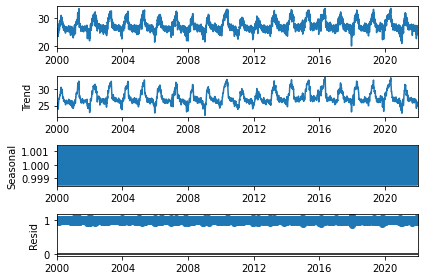

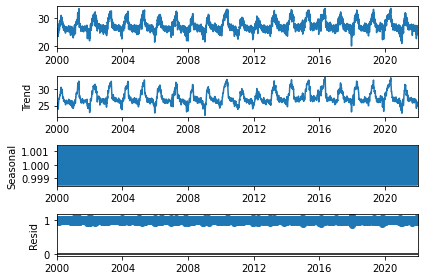

In [ ]:
decompose_result = seasonal_decompose(data,model='multiplicative')
decompose_result.plot()

#AR

In [ ]:
window = 8
ar = AutoReg(train, lags = 8)
ar_fit = ar.fit()
coef = ar_fit.params
coef

array([ 0.89175769,  0.85141522, -0.06898399,  0.0475148 ,  0.02907885,
        0.04795226, -0.00997218,  0.04592183,  0.02455661])

In [ ]:
train.mean()

27.411111567419578

In [ ]:
history = train[len(train)-window:]
history = [history[i] for i in range(len(history))]
predictions = []
history

[]

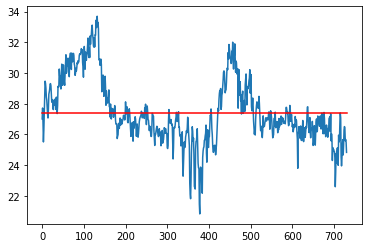

RMSE: 2.1163796482839152


In [ ]:
for t in range(len(test)):
  length = len(history)
  lag = [history[i] for i in range(length-window, length)]
  yhat = coef[0]
  for d in range(window):
    yhat += coef[d+1] * lag[window-d-1]
  obs = test[t]
  predictions.append(yhat)
  history.append(obs)
  #print('predicted=%f, expected=%f' % (yhat, obs))

pyplot.plot(test)
pyplot.plot(predictions[:len(test)], color='red')
pyplot.show()

print('RMSE:', sqrt(mean_squared_error(test, predictions[:len(test)])))

# MA (bỏ MA)

In [ ]:
ma = data.rolling(window=1).mean()
ma_train, ma_test = ma[data.index < '2020-01-01'].values, ma[data.index >= '2020-01-01'].values

In [6]:
history = [x for x in train]
    
predictions = []
i = 0
for t in range(len(test)):
  model = sm.tsa.arima.ARIMA(history, order=(0,0,12))
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)
  print('predicted=%f, expected=%f' % (yhat, obs), i)
  i = i+1

predicted=27.937390, expected=27.010000 0
predicted=27.030595, expected=27.720000 1
predicted=27.844928, expected=26.790000 2
predicted=26.771940, expected=25.510000 3
predicted=25.689655, expected=26.250000 4
predicted=26.495115, expected=27.400000 5
predicted=27.499556, expected=28.830000 6
predicted=28.674880, expected=29.470000 7
predicted=29.271511, expected=29.340000 8
predicted=29.122055, expected=29.010000 9
predicted=28.767226, expected=28.440000 10
predicted=28.399642, expected=28.240000 11
predicted=28.348725, expected=27.810000 12
predicted=27.878375, expected=27.300000 13
predicted=27.331183, expected=27.070000 14
predicted=27.122579, expected=27.680000 15
predicted=27.525297, expected=28.620000 16
predicted=28.229381, expected=28.760000 17
predicted=28.354439, expected=28.940000 18
predicted=28.661200, expected=29.270000 19
predicted=29.139837, expected=29.310000 20
predicted=29.253587, expected=29.170000 21
predicted=29.152943, expected=28.640000 22
predicted=28.664498, 

In [7]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 8035
Model:                ARIMA(0, 0, 12)   Log Likelihood               -8084.067
Date:                Fri, 12 Aug 2022   AIC                          16196.134
Time:                        10:51:39   BIC                          16294.016
Sample:                             0   HQIC                         16229.630
                               - 8035                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.4145      0.059    464.081      0.000      27.299      27.530
ma.L1          0.9710      0.009    108.971      0.000       0.953       0.988
ma.L2          0.8538      0.013     65.961      0.000       0.828       0.879
ma.L3          0.7843      0.015     51.983      0.000       0.755       0.814
ma.L4          0.7361      0.016     44.907      0.000       0.704       0.768
ma.L5          0.7061      0.017     40.701      0.000       0.672       0.740
ma.L6          0.6311      0.018     35.211      0.000       0.596       0.666
ma.L7          0.5760      0.019     30.906      0.000       0.540       0.613
ma.L8          0.5022      0.018     27.427      0.000       0.466       0.538
ma.L9          0.4188      0.017     24.335      0.000       0.385       0.453
ma.L10         0.3194      0.016     20.530      0.000       0.289       0.350
ma.L11         0.2142      0.014     15.552      0.000       0.187       0.241
ma.L12         0.0927      0.010      9.251      0.000       0.073       0.112
sigma2         0.4378      0.005     85.258      0.000       0.428       0.448
===================================================================================
Ljung-Box (L1) (Q):                   1.15   Jarque-Bera (JB):              1071.78
Prob(Q):                              0.28   Prob(JB):                         0.00
Heteroskedasticity (H):               1.14   Skew:                            -0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
rmse, r2 = sqrt(mean_squared_error(test, predictions)), r2_score(test, predictions)
rmse, r2

(0.6834878721154073, 0.8956195449313464)

In [ ]:
x=[int(i) for i in range(1,15)]
x=np.array(x)
x=pd.Series(x)

###########

plt.xlabel("time step")
plt.ylabel("R_square", color="b")
plt.tick_params(axis="y", labelcolor="b")
#thay gia tri r[1:] la con so cua r_square
plt.plot(x, r[1:], "b-")
##############
plt.twinx()
plt.ylabel("RMSE", color="r")
#thay gia tri r[1:] la con so cua rmse
plt.tick_params(axis="y", labelcolor="r")
plt.plot(x, rm[1:], "r-")

MSE: 0.22567604499164007


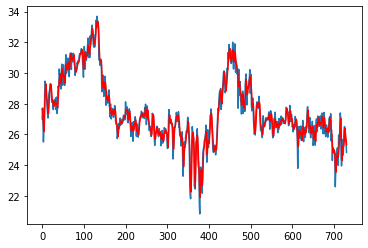

In [ ]:
pyplot.plot(test)
pyplot.plot(ma_test, color='red')
print('MSE:', mean_squared_error(test, ma_test))

# ARIMA 

## Function to calculate $R^2$ and RMSE

In [ ]:
def evaluate_arima_model(X, arima_order):
  train_size = int(len(X)*0.8)
  train, test = X[0:train_size], X[train_size:]
  history = [x for x in train]
  
  predictions = []
  for t in range(len(test)):
    model = sm.tsa.arima.ARIMA(history, order=arima_order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test[t])
    # print('predicted=%f, expected=%f' % (yhat, test[t]))

  rmse, r2 = sqrt(mean_squared_error(test, predictions)), r2_score(test, predictions)
  return rmse, r2

## Train model

### Generate order (p,d,p)


In [ ]:
def generate_orders(p_values, d_values, q_values):
  orders = []
  for p in p_values:
    for d in d_values:
      for q in q_values:
        order = (p,d,q)
        orders.append(order)
  return orders

In [ ]:
p_values = [3, 5, 7]
d_values = range(1, 3)
q_values = range(1, 3)

orders = generate_orders(p_values, d_values, q_values)

for order in orders:
  print(order)

(3, 1, 1)
(3, 1, 2)
(3, 2, 1)
(3, 2, 2)
(5, 1, 1)
(5, 1, 2)
(5, 2, 1)
(5, 2, 2)
(7, 1, 1)
(7, 1, 2)
(7, 2, 1)
(7, 2, 2)


In [ ]:
history = [x for x in train]
    
predictions = []
i = 0
for t in range(len(test)):
  model = sm.tsa.arima.ARIMA(history, order=(7,1,2))
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)
  print('predicted=%f, expected=%f' % (yhat, obs), i)
  i = i+1

predicted=27.676897, expected=27.010000 0
predicted=26.882191, expected=27.720000 1
predicted=27.650346, expected=26.790000 2
predicted=26.762434, expected=25.510000 3
predicted=25.784547, expected=26.250000 4
predicted=26.454783, expected=27.400000 5
predicted=27.360161, expected=28.830000 6
predicted=28.429353, expected=29.470000 7
predicted=28.948465, expected=29.340000 8
predicted=28.883103, expected=29.010000 9
predicted=28.699467, expected=28.440000 10
predicted=28.312493, expected=28.240000 11
predicted=28.204679, expected=27.810000 12
predicted=27.859476, expected=27.300000 13
predicted=27.449144, expected=27.070000 14
predicted=27.263260, expected=27.680000 15
predicted=27.773483, expected=28.620000 16
predicted=28.488333, expected=28.760000 17
predicted=28.549903, expected=28.940000 18
predicted=28.732652, expected=29.270000 19
predicted=29.046970, expected=29.310000 20
predicted=29.090318, expected=29.170000 21
predicted=29.001277, expected=28.640000 22
predicted=28.600969, 

/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


predicted=27.890436, expected=26.870000 507
predicted=27.192536, expected=26.470000 508
predicted=26.850245, expected=26.010000 509
predicted=26.431027, expected=26.300000 510
predicted=26.626073, expected=25.960000 511
predicted=26.263177, expected=26.970000 512
predicted=27.097712, expected=27.520000 513
predicted=27.452088, expected=27.880000 514
predicted=27.735701, expected=28.120000 515
predicted=27.938257, expected=28.090000 516
predicted=27.949263, expected=27.970000 517
predicted=27.841697, expected=27.700000 518
predicted=27.662626, expected=27.750000 519
predicted=27.723617, expected=28.480000 520
predicted=28.354242, expected=28.010000 521
predicted=27.897086, expected=27.330000 522
predicted=27.385900, expected=26.650000 523
predicted=26.855166, expected=26.250000 524
predicted=26.542790, expected=26.540000 525
predicted=26.749213, expected=26.220000 526
predicted=26.420785, expected=25.990000 527
predicted=26.213428, expected=25.790000 528
predicted=26.030243, expected=26

/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


predicted=26.779538, expected=26.730000 581


...

predicted=26.757350, expected=26.860000 582
predicted=26.864536, expected=26.690000 583


/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


predicted=26.700062, expected=27.150000 584
predicted=27.119723, expected=27.760000 585
predicted=27.598021, expected=27.760000 586
predicted=27.578869, expected=27.530000 587
predicted=27.407769, expected=27.360000 588
predicted=27.321428, expected=27.460000 589
predicted=27.418773, expected=26.860000 590


/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


predicted=26.896811, expected=26.570000 591
predicted=26.693810, expected=26.650000 592
predicted=26.769461, expected=27.080000 593
predicted=27.111627, expected=27.890000 594
predicted=27.747724, expected=27.660000 595
predicted=27.516218, expected=26.850000 596
predicted=26.872780, expected=26.940000 597
predicted=27.027894, expected=27.300000 598
predicted=27.304877, expected=26.900000 599
predicted=26.909267, expected=26.490000 600
predicted=26.602197, expected=26.660000 601
predicted=26.776868, expected=26.170000 602
predicted=26.308281, expected=26.350000 603
predicted=26.480701, expected=26.480000 604
predicted=26.553627, expected=26.650000 605
predicted=26.682479, expected=26.470000 606
predicted=26.490236, expected=27.170000 607
predicted=27.131353, expected=26.860000 608
predicted=26.783095, expected=26.960000 609
predicted=26.933361, expected=26.900000 610
predicted=26.857580, expected=26.160000 611
predicted=26.261002, expected=25.710000 612
predicted=25.892575, expected=23

In [ ]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 8035
Model:                 ARIMA(7, 1, 2)   Log Likelihood               -7545.824
Date:                Wed, 06 Jul 2022   AIC                          15111.649
Time:                        18:09:48   BIC                          15181.563
Sample:                             0   HQIC                         15135.574
                               - 8035                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0483      0.360      0.134      0.893      -0.657       0.754
ar.L2          0.3384      0.234      1.445      0.148      -0.121       0.797
ar.L3         -0.0515      0.040     -1.298      0.194      -0.129       0.026
ar.L4          0.0064      0.015      0.438      0.662      -0.022       0.035
ar.L5          0.0172      0.013      1.314      0.189      -0.008       0.043
ar.L6         -0.0189      0.015     -1.295      0.195      -0.048       0.010
ar.L7          0.0022      0.019      0.113      0.910      -0.035       0.039
ma.L1         -0.1901      0.360     -0.528      0.597      -0.895       0.515
ma.L2         -0.5270      0.284     -1.856      0.063      -1.084       0.030
sigma2         0.3831      0.004     92.016      0.000       0.375       0.391
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2367.06
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.13   Skew:                            -0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
rmse, r2 = sqrt(mean_squared_error(test, predictions)), r2_score(test, predictions)
rmse, r2

(0.6284059591273684, 0.911765556714753)

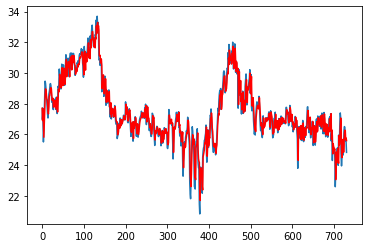

In [ ]:
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()